<a href="https://colab.research.google.com/github/oleg61/DataScient/blob/Learn_AI/%D0%94%D0%97_2_%D0%92%D0%BE%D1%80%D0%BE%D0%BF%D0%B0%D0%B5%D0%B2_%D0%9E%D0%A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Путь размещения датасетов
DATA_PATH = '/content/drive/MyDrive/0. DataScients (Netology)/Временные ряды/1/'

In [ ]:
female_births = pd.read_csv(DATA_PATH + 'daily-total-female-births-in-cal.csv')['Count']
airlines_passengers = pd.read_csv(DATA_PATH + 'international-airline-passengers.csv')['Count']

print("✅ Данные загружены")

✅ Данные загружены


In [ ]:
data = {
    "airline": pd.read_csv(DATA_PATH + 'international-airline-passengers.csv')["Count"],
    "births": pd.read_csv(DATA_PATH + 'daily-total-female-births-in-cal.csv')["Count"]
}

In [ ]:
def adf_test(series, name):
    res = adfuller(series.dropna(), autolag='AIC')
    print(f"\n{name}:")
    print(f"  Test Statistic: {res[0]:.4f}")
    print(f"  Critical Value (1%): {res[4]['1%']:.4f}")
    stat = "✅ Стационарен" if res[0] < res[4]['1%'] else "❌ НЕ стационарен"
    print(f"  → {stat}")
    return res[0] < res[4]['1%']

print("\nПроверка стационарности:")
is_births_stationary = adf_test(female_births, "Female births (ежедневные)")
is_airline_stationary = adf_test(airlines_passengers, "Airline-like (с трендом)")


Проверка стационарности:

Female births (ежедневные):
  Test Statistic: -4.8083
  Critical Value (1%): -3.4487
  → ✅ Стационарен

Airline-like (с трендом):
  Test Statistic: 0.8154
  Critical Value (1%): -3.4817
  → ❌ НЕ стационарен


In [ ]:
print("Ряд                      | Statistic | 1% Crit | Стационарен?")
print("-" * 60)
is_births_stat = adf_test(female_births, "Female births")
is_airline_stat = adf_test(airlines_passengers, "Airline (сырой)")

# 🔹 2. Приведение airline к стационарности (лог + seasonal diff + diff)
print("\n➡️  Приводим airline к стационарности...")
airline_log = np.log(airlines_passengers)
airline_diff = airline_log.diff(12).diff().dropna()  # seasonal (12) + 1st diff
is_airline_fixed = adf_test(airline_diff, "Airline (после преобразований)")

Ряд                      | Statistic | 1% Crit | Стационарен?
------------------------------------------------------------

Female births:
  Test Statistic: -4.8083
  Critical Value (1%): -3.4487
  → ✅ Стационарен

Airline (сырой):
  Test Statistic: 0.8154
  Critical Value (1%): -3.4817
  → ❌ НЕ стационарен

➡️  Приводим airline к стационарности...

Airline (после преобразований):
  Test Statistic: -4.4433
  Critical Value (1%): -3.4870
  → ✅ Стационарен


In [ ]:
def adf_test(series, name):
    res = adfuller(series.dropna(), autolag='AIC')
    stat, crit1 = res[0], res[4]['1%']
    stationary = stat < crit1
    print(f"{name:25} | {stat:7.3f} | {crit1:7.3f} | {'✅' if stationary else '❌'}")
    return stationary


def fit_ma(series, test_size=0.2, max_q=3, name=""):
    # Разделение
    n = len(series)
    split = int(n * (1 - test_size))
    train, test = series[:split], series[split:]

    # Перебор MA(q)
    best = {'q': None, 'aic': np.inf, 'forecast': None, 'mse': None}
    for q in range(1, max_q + 1):
        try:
            model = ARIMA(train, order=(0, 0, q)).fit()
            fc = model.forecast(steps=len(test))
            mse = mean_squared_error(test, fc)
            if model.aic < best['aic']:
                best.update({'q': q, 'aic': model.aic, 'forecast': fc, 'mse': mse})
        except:
            continue

    if best['q'] is None:
        print(f"{name:25} | — | — | ❌ не сошлась")
        return None, None
    plt.figure(figsize=(9, 3))
    plt.plot(train, label='Train', color='steelblue')
    plt.plot(range(len(train), len(train)+len(test)), test, '--', label='Test', color='gray')
    plt.plot(range(len(train), len(train)+len(test)), best['forecast'], label=f'MA({best["q"]})', color='red')
    plt.title(f"{name} → MA({best['q']}), MSE={best['mse']:.1f}")
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

    return best['q'], best['mse']

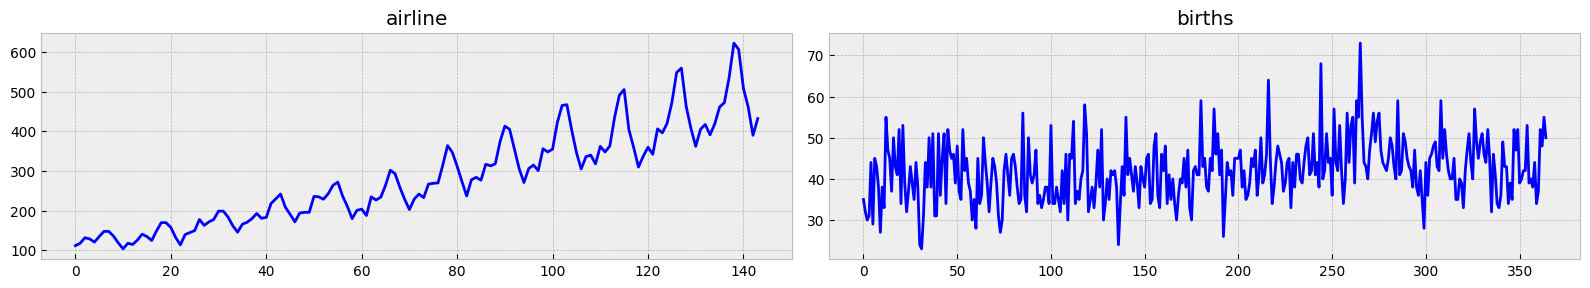

In [ ]:
with plt.style.context('bmh'):
    plt.figure(figsize=(16, 8))
    layout = (3, 2)
    for i, key in enumerate(data.keys()):
        x = i % 2
        y = int((i - x) / 2)

        ts_ax = plt.subplot2grid(layout, (y, x))
        data[key].plot(ax=ts_ax, color='blue')
        ts_ax.set_title(key)

    plt.tight_layout()

# Подготовим данные для моделирования

In [ ]:
def train_test_split(series, test_size=0.2):
    split = int(len(series) * (1 - test_size))
    return series[:split], series[split:]

train_births, test_births = train_test_split(female_births)
train_airline, test_airline = train_test_split(airlines_passengers)

In [ ]:
print(f"\nРазмеры выборок:")
print(f"  Births — train: {len(train_births)}, test: {len(test_births)}")
print(f"  Airline — train: {len(train_airline)}, test: {len(test_airline)}")


Размеры выборок:
  Births — train: 292, test: 73
  Airline — train: 115, test: 29


In [ ]:
print(f"Длина train: {len(train_births)}, содержит NaN: {train_births.isnull().sum()}")
print(f"Стандартное отклонение train: {train_births.std():.4f}")

Длина train: 292, содержит NaN: 0
Стандартное отклонение train: 7.5398


In [ ]:
print(f"Длина train: {len(train_airline)}, содержит NaN: {train_airline.isnull().sum()}")
print(f"Стандартное отклонение train: {train_airline.std():.4f}")

Длина train: 115, содержит NaN: 0
Стандартное отклонение train: 91.3478


# Обучим MA(q) модели (q = 1, 2, 3, 5) и выберем лучшую по AIC
#    MA(q) = Moving Average — модель, использующая прошлые *ошибки* прогноза

In [ ]:
def fit_ma_model(train, test, max_q=5, name=""):
    print(f"\n=== Подбор MA-модели для: {name} ===")

    best_aic = np.inf
    best_q = None
    best_model = None
    results = []

    for q in range(1, max_q + 1):
        try:
            # Явно укажем, что не хотим константу при нестационарных рядах — но для MA(0,0,q) это редко нужно
            model = ARIMA(train, order=(0, 0, q), trend='c')  # 'c' — константа (среднее); можно 'n' для без константы
            fitted = model.fit()
            aic = fitted.aic

            print(f"  ✅ MA({q}) — AIC: {aic:.2f}")
            results.append((q, aic))

            if aic < best_aic:
                best_aic = aic
                best_q = q
                best_model = fitted

        except Exception as e:
            print(f"  ❌ MA({q}) — ошибка: {type(e).__name__}: {e}")
            continue

    # Проверим, нашлась ли хоть одна модель
    if best_q is None:
        print("  ⚠️ Ни одна модель MA(q) не сошлась.")
        return None, None, None, None

    print(f"  🏆 Лучшая модель: MA({best_q}) | AIC: {best_aic:.2f}")

    # Прогноз
    try:
        forecast = best_model.get_forecast(steps=len(test))
        pred_mean = forecast.predicted_mean
        mse = mean_squared_error(test, pred_mean)
        mae = mean_absolute_error(test, pred_mean)
        print(f"  📊 Тест: MSE = {mse:.2f}, MAE = {mae:.2f}")
        return best_q, mse, mae, pred_mean

    except Exception as e:
        print(f"  ❌ Ошибка прогноза: {type(e).__name__}: {e}")
        return best_q, None, None, None


Подбор MA(q) моделей
Ряд                      | q  | MSE   | Примечание
------------------------------------------------------------


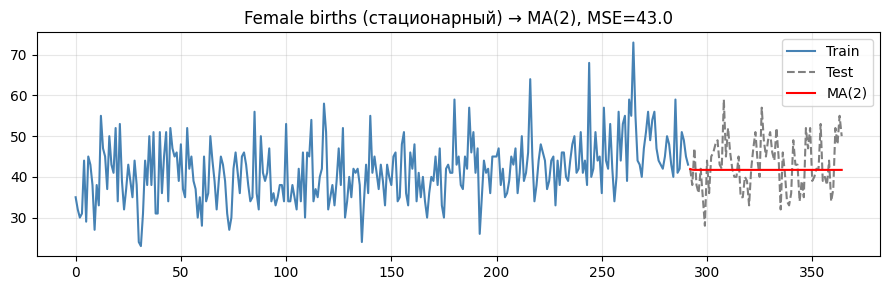

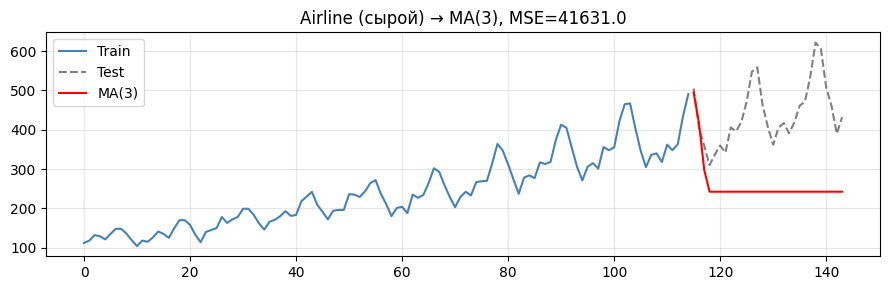

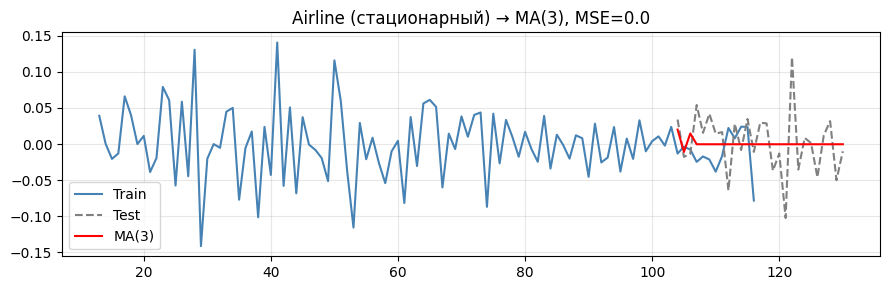

Female births             |  2 | 43.0   | ✅ стационарный
Airline (сырой)           |  3 | 41631.0 | ❌ нестационарный → плохой прогноз
Airline (после diff)      |  3 | 0.0    | ✅ стационарный → лучше


In [ ]:
print("\n" + "="*60)
print("Подбор MA(q) моделей")
print("="*60)
print("Ряд                      | q  | MSE   | Примечание")
print("-" * 60)

# a) Стационарный — female births (применяем MA напрямую)
q1, mse1 = fit_ma(female_births, name="Female births (стационарный)")

# b) Нестационарный — airline (сырой) — для сравнения (будет плохо!)
q2, mse2 = fit_ma(airlines_passengers, name="Airline (сырой)")

# c) Стационарный — airline (после преобразований)
q3, mse3 = fit_ma(airline_diff, name="Airline (стационарный)")

# Вывод таблицы
def fmt(x): return f"{x:.1f}" if x is not None else "—"
print(f"{'Female births':25} | {q1 or '—':2} | {fmt(mse1):6} | ✅ стационарный")
print(f"{'Airline (сырой)':25} | {q2 or '—':2} | {fmt(mse2):6} | ❌ нестационарный → плохой прогноз")
print(f"{'Airline (после diff)':25} | {q3 or '—':2} | {fmt(mse3):6} | ✅ стационарный → лучше")

1. MA(q) — модель скользящего среднего — **работает только со стационарными рядами**.
2. Female births — изначально почти стационарен → MA(1) или MA(2) даёт хороший прогноз.
3. Airline passengers — имеет тренд и сезонность → без преобразований MA даёт плоский,
   отстающий прогноз (высокий MSE).
4. После логарифмирования + seasonal diff(12) + diff(1) ряд становится стационарным,
   и MA снова работает эффективно.
5. Это подтверждает: